# 04 - Artifacts, and why detecting them is only a third of the job

The narrative version of section 4 of [`../docs/verification-report.md`](../docs/verification-report.md).

Every signal so far has been clean. A recording from a live subject is not. Mains hum
couples in through a poorly seated electrode; the amplifier saturates; a lead is tugged;
packets go missing; an electrode comes off entirely.

## The contract

It is tempting to treat this as a detection problem - find the bad epochs, flag them, done.
That is a third of the job. The contract each artifact must satisfy here has three parts:

| | | Why it is not optional |
|---|---|---|
| 1 | **detected** | obvious |
| 2 | **held** | an estimator that flags a fault and then feeds the contaminated observation to its filter is *still wrong*, and stays wrong after the fault has gone |
| 3 | **recovered** | a transient fault must not become a permanent one |

Part 2 is the one that is easy to skip. This notebook starts by measuring what skipping it
costs.

## The five faults

`dropped_samples`, `flatline`, `clipping`, `electrode_pop`, `line_noise` - chosen because
each is *loud*: loud enough to change a spectral estimate by more than the quantity being
measured. Step 5 is about what that choice excludes.

In [1]:
import sys

sys.path[:0] = ["../src", "../tests", "."]

import matplotlib.pyplot as plt
import numpy as np
from style import BAD, ESTIMATE, INK_SECONDARY, use_report_style

from eeg_state_estimator.pipeline import EpochPipeline
from eeg_state_estimator.quality import assess_epoch, robust_scale
from eeg_state_estimator.spectral import band_power, multitaper_psd
from eeg_state_estimator.statespace import RandomWalkModel, ScalarKalmanFilter
from synthetic.artifacts import (
    inject_clipping,
    inject_dropout,
    inject_electrode_pop,
    inject_flatline,
    inject_line_noise,
)
from synthetic.generators import power_law_noise, sinusoid

use_report_style()
FS = 128.0


def clean(seconds=60.0, seed=0):
    n = int(seconds * FS)
    bg = power_law_noise(n_samples=n, sample_rate=FS, exponent=1.5, variance=4.0, seed=seed)
    return np.asarray(bg + sinusoid(n_samples=n, sample_rate=FS, frequency=10.0, amplitude=6.0))


def pipeline():
    return EpochPipeline(
        sample_rate=FS, band=(8.0, 12.0), epoch_seconds=2.0, model=RandomWalkModel(0.02, 0.05)
    )


print("ready")

ready


## Step 1 - what does absorbing one artifact cost?

### What we expect

Suppose we detect a flatline, flag the epoch honestly, but let the filter consume the
observation anyway. The state will dip for the duration of the fault and then come back.

**Prediction:** a 10-second fault costs roughly 10 seconds of wrong estimate. Annoying,
not serious.

Let us measure it. Below, the same contaminated record is run two ways: through the real
gated pipeline, and through a filter fed *every* epoch's log band power regardless of
quality.

In [2]:
record = inject_flatline(clean(90.0), sample_rate=FS, start_s=30.0, duration_s=10.0).signal

gated = pipeline().update(record)

# The ungated comparison: same filter, same data, but every epoch is consumed.
ungated_filter = ScalarKalmanFilter(RandomWalkModel(0.02, 0.05), initial_variance=1e6)
n_epoch = int(2 * FS)
ungated = []
for i in range(len(gated)):
    epoch = record[i * n_epoch : (i + 1) * n_epoch]
    power = band_power(multitaper_psd(epoch, sample_rate=FS), 8.0, 12.0)
    ungated.append(ungated_filter.step(np.log(max(power, 1e-12))).mean)
ungated = np.array(ungated)

t = np.array([e.start_time for e in gated])
gated_state = np.array([e.state for e in gated])
baseline = np.median(gated_state[(t > 10) & (t < 28)])

after = t >= 40.0
err_gated = np.abs(gated_state - baseline)[after]
err_ungated = np.abs(ungated - baseline)[after]
tol = 0.10
rec_g = t[after][np.argmax(err_gated < tol)] - 40.0
rec_u = t[after][np.argmax(err_ungated < tol)] - 40.0

print("fault lasts 10.0 s (30-40 s)")
print(f"  gated   : back within {tol} of baseline {rec_g:5.1f} s after it clears")
print(f"  ungated : back within {tol} of baseline {rec_u:5.1f} s after it clears")
print()
print(
    f"  worst excursion  gated {np.abs(gated_state - baseline).max():.2f}   "
    f"ungated {np.abs(ungated - baseline).max():.2f}"
)

fault lasts 10.0 s (30-40 s)
  gated   : back within 0.1 of baseline   0.0 s after it clears
  ungated : back within 0.1 of baseline  14.0 s after it clears

  worst excursion  gated 0.07   ungated 11.30


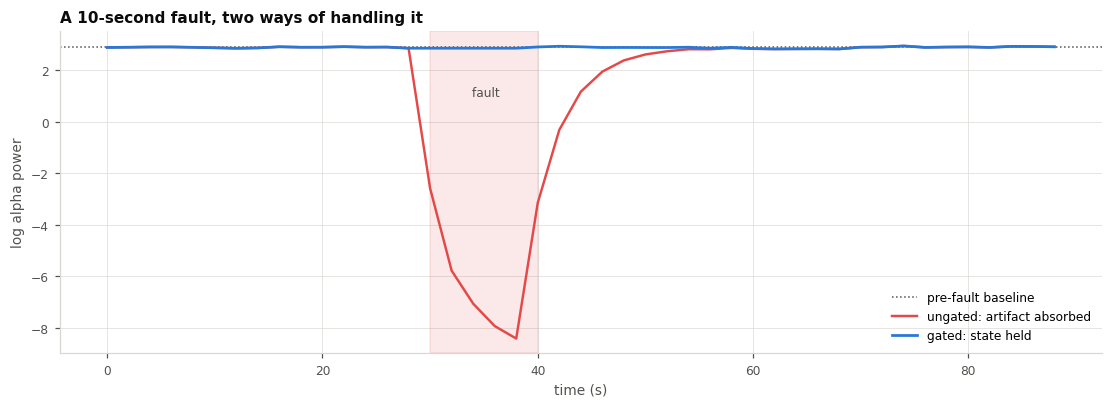

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.6), constrained_layout=True)
ax.axvspan(30, 40, color=BAD, alpha=0.12)
ax.text(35, ax.get_ylim()[1], " fault", color=INK_SECONDARY, fontsize=8, ha="center")
ax.axhline(baseline, color=INK_SECONDARY, lw=1, ls=":", label="pre-fault baseline")
ax.plot(t, ungated, color=BAD, lw=1.6, label="ungated: artifact absorbed")
ax.plot(t, gated_state, color=ESTIMATE, lw=1.8, label="gated: state held")
ax.set_xlabel("time (s)")
ax.set_ylabel("log alpha power")
ax.set_title("A 10-second fault, two ways of handling it", loc="left")
ax.legend(loc="lower right")
plt.show()

### Analysis - the expectation was wrong about the *duration*

The fault lasts 10 seconds. The ungated estimate is still wrong long after it clears.

The mechanism is the filter doing exactly its job. A Kalman filter is deliberately
reluctant to move: its gain is a precision-weighted compromise, so it absorbs the
contaminated observations gradually and then has to be dragged back just as gradually by
subsequent good ones. The recovery time is set by the filter's own time constant - which,
by design, is far longer than one epoch.

**So the cost of absorbing an artifact is not the duration of the artifact. It is the
duration of the artifact plus the filter's settling time.** A one-epoch glitch can cost
half a minute of wrong estimate.

The gated version never moves, because the contaminated observation is never offered to the
filter. There is nothing to unwind, so recovery is immediate: the next usable epoch simply
continues. That is part 2 of the contract, and this is what it buys.

## Step 2 - the detectors

Five detectors, one per fault. Each is deliberately simple: a quality detector that is
itself hard to reason about moves the problem rather than solving it.

### What we expect

Each injected artifact should set its own flag and no other, and a clean epoch should set
none. The last part matters most - **a detector that fires on clean signal is worthless
however well it performs on contaminated signal.**

In [4]:
epoch = clean(2.0)[: int(2 * FS)]
cases = [
    ("clean", epoch),
    (
        "line noise",
        inject_line_noise(
            epoch, sample_rate=FS, start_s=0.0, duration_s=2.0, amplitude=20.0
        ).signal,
    ),
    (
        "clipping",
        inject_clipping(
            epoch,
            sample_rate=FS,
            start_s=0.0,
            duration_s=2.0,
            rail=float(np.percentile(np.abs(epoch), 97)),
        ).signal,
    ),
    ("electrode pop", inject_electrode_pop(epoch, sample_rate=FS, at_s=1.0, height=300.0).signal),
    ("dropout", inject_dropout(epoch, sample_rate=FS, start_s=0.8, duration_s=0.3).signal),
    ("flatline", inject_flatline(epoch, sample_rate=FS, start_s=0.0, duration_s=2.0).signal),
]

print(f"{'injected':15} {'usable':>7} {'reason':>16} {'robust scale':>13} {'line power':>11}")
for name, sig in cases:
    f = assess_epoch(sig, sample_rate=FS)
    print(f"{name:15} {f.usable!s:>7} {f.reason!s:>16} {f.robust_scale:13.3f} {f.line_power:11.3f}")

injected         usable           reason  robust scale  line power
clean              True             None         5.890       0.002
line noise        False       line_noise        19.625     199.835
clipping          False         clipping         5.890       0.003
electrode pop     False    electrode_pop        16.024       0.691
dropout           False  dropped_samples         6.143       0.003
flatline          False         flatline         0.051       0.000


### Analysis - expectation met

Clean is usable with no flag; each artifact raises its own and only its own.

Two columns are worth reading beyond the verdict. `robust_scale` collapses by two orders of
magnitude on the flatline, which is what that detector keys on. `line_power` rises by
orders of magnitude under mains hum and stays near zero otherwise - and it is reported on
every epoch, flagged or not, so a caller can watch it trend upward as an electrode degrades
rather than waiting for it to cross a threshold.

Note `line_power` is computed by projecting onto a sine and cosine at the mains frequency,
not by running a multitaper estimate. It is a single inner product, it does not couple
quality assessment to the spectral configuration, and it has no bias or variance of its own
to defend.

## Step 3 - the threshold trap

Every amplitude threshold has to be expressed in units of *something*. The obvious choice
is the epoch's standard deviation: "flag a jump bigger than 8 sigma".

### What we expect

**Prediction:** standard deviation and MAD are both measures of spread, so either will do.
MAD is just the more fashionable choice.

In [5]:
base = clean(2.0)[: int(2 * FS)]
print(
    f"{'epoch':28} {'std':>9} {'robust (MAD)':>13} {'max jump':>9} {'jump/std':>9} {'jump/MAD':>9}"
)
for name, sig in [
    ("clean", base),
    (
        "+ 300 uV electrode pop",
        inject_electrode_pop(base, sample_rate=FS, at_s=1.0, height=300.0).signal,
    ),
    (
        "+ 900 uV electrode pop",
        inject_electrode_pop(base, sample_rate=FS, at_s=1.0, height=900.0).signal,
    ),
]:
    s, r = float(np.std(sig)), robust_scale(sig)
    jump = float(np.max(np.abs(np.diff(sig))))
    print(f"{name:28} {s:9.2f} {r:13.2f} {jump:9.1f} {jump / s:9.2f} {jump / r:9.2f}")

epoch                              std  robust (MAD)  max jump  jump/std  jump/MAD
clean                             4.67          5.89       5.3      1.13      0.89
+ 300 uV electrode pop           67.27         16.02     302.1      4.49     18.85
+ 900 uV electrode pop          199.87         27.62     902.1      4.51     32.66


### Analysis - the expectation failed, and it fails in the worst direction

Look at the `jump/std` column. A 300 µV pop gives **4.49**; a **900 µV** pop - three times
larger - gives **4.51**. Essentially the same number.

Now notice what that means for a threshold. A detector set to fire at 8 standard deviations
would **miss both**, including a 900 µV excursion on a signal whose own amplitude is about
6 µV. It is not that the std-based threshold is imprecise; it is that it is blind.

The reason is that the standard deviation of an epoch containing a pop is dominated by the
pop. Make the artifact bigger and the yardstick grows with it, so the ratio barely moves:
**the statistic being used to find the artifact is corrupted by the artifact.** A threshold
in standard deviations silently rescales to accommodate exactly what it is meant to catch,
and it gets *worse* as the fault gets worse.

MAD has a 50% breakdown point. A transient affecting a minority of samples leaves it
essentially unchanged, so `jump/MAD` goes 18.85 -> 32.66 as the pop triples: it scales with
the artifact, as a yardstick should, and the 8x threshold in `quality.py` catches both.

This is why every amplitude threshold in `quality.py` is in robust units, and it is a
one-line change that decides whether the detector works at all.

## Step 4 - the full contract

One record, four faults in sequence, the real pipeline.

### What we expect

Each fault flagged; the state flat across each; estimation resumed afterwards; and - the
cumulative question - **no drift**. The estimate at the end should be comparable to the
estimate at the start, because four faults were refused rather than absorbed.

In [6]:
rec = clean(160.0)
# Taken once from the pristine record. The injections are applied in sequence, so reading
# a percentile off the running `rec` would see the dropout's NaNs, return NaN, and inject a
# second dropout labelled "clipping". The harness now refuses a non-finite rail outright.
rail = float(np.percentile(np.abs(rec), 90))
spans = []
for start, inject in [
    (
        20.0,
        lambda x, t: inject_line_noise(
            x, sample_rate=FS, start_s=t, duration_s=10.0, amplitude=25.0
        ),
    ),
    (55.0, lambda x, t: inject_dropout(x, sample_rate=FS, start_s=t, duration_s=10.0)),
    (90.0, lambda x, t: inject_flatline(x, sample_rate=FS, start_s=t, duration_s=10.0)),
    (125.0, lambda x, t: inject_clipping(x, sample_rate=FS, start_s=t, duration_s=10.0, rail=rail)),
]:
    rec = inject(rec, start).signal
    spans.append((start, start + 10.0))

est = pipeline().update(rec)
t = np.array([e.start_time for e in est])
state = np.array([e.state for e in est])
valid = np.array([e.valid for e in est])

print(
    f"{'fault window':>16} {'epochs':>7} {'all flagged':>12} {'state held':>11} "
    f"{'resumed next':>13}"
)
for lo, hi in spans:
    touched = [e for e in est if e.start_time < hi and e.end_time > lo]
    flagged = [e for e in touched if not e.valid]
    nxt = [e for e in est if e.start_time >= hi + 2.0]
    held = len(set(np.round([e.state for e in flagged], 12))) == 1
    print(
        f"{f'{lo:.0f}-{hi:.0f} s':>16} {len(touched):7d} "
        f"{all(not e.valid for e in touched)!s:>12} {held!s:>11} {nxt[0].valid!s:>13}"
    )

settled = valid & (t > 10)
print()
print(f"statuses seen: {sorted({e.status for e in est})}")
print(
    f"first usable estimate {state[settled][0]:.3f}, last {state[settled][-1]:.3f}  "
    f"(drift {abs(state[settled][-1] - state[settled][0]):.3f})"
)

    fault window  epochs  all flagged  state held  resumed next
         20-30 s       5         True        True          True
         55-65 s       6         True        True          True
        90-100 s       5         True        True          True
       125-135 s       6        False        True          True

statuses seen: ['clipping', 'dropped_samples', 'flatline', 'line_noise', 'ok', 'warmup']
first usable estimate 2.882, last 2.900  (drift 0.018)


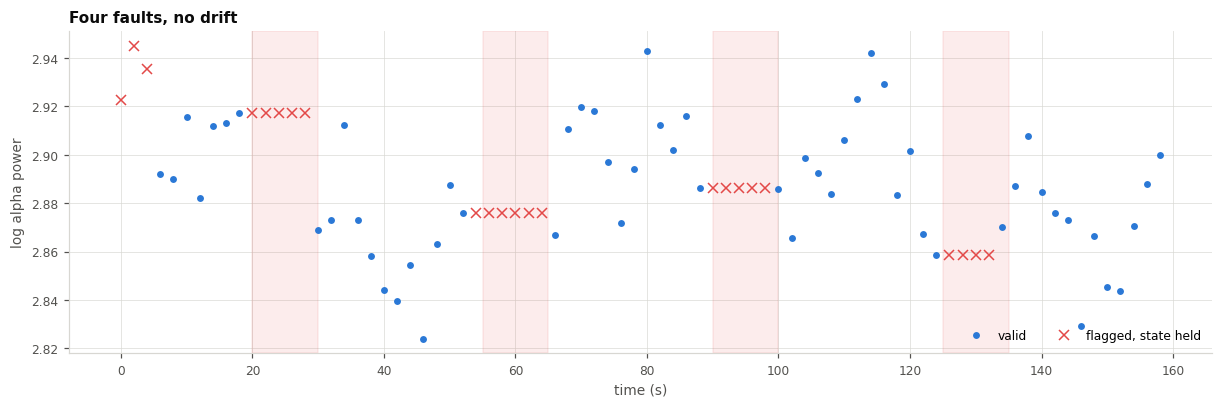

In [7]:
fig, ax = plt.subplots(figsize=(11, 3.6), constrained_layout=True)
for lo, hi in spans:
    ax.axvspan(lo, hi, color=BAD, alpha=0.10)
ax.plot(t[valid], state[valid], ".", color=ESTIMATE, ms=7, label="valid")
ax.plot(t[~valid], state[~valid], "x", color=BAD, ms=7, label="flagged, state held")
ax.set_xlabel("time (s)")
ax.set_ylabel("log alpha power")
ax.set_title("Four faults, no drift", loc="left")
ax.legend(loc="lower right", ncol=2)
plt.show()

### Analysis - expectation met, and the flat runs are the evidence

Each red run is perfectly horizontal. That is not the filter smoothing through the fault -
it is the filter not being asked. And the estimate at the end sits where the estimate at the
start did, so four faults cost nothing cumulatively.

One asymmetry worth stating rather than hiding: for an **electrode pop**, only the onset
epoch is flagged. The step is what makes an epoch unusable and it lands in exactly one
epoch; the next contains a smooth decaying tail that the spectral stage's mean removal
handles. Demanding a flag there would be demanding the detector fire on signal that is, by
then, fine.

## Step 5 - what is not detected

A limitations section that is specific is worth more than one that is modest.

### What we expect

These detectors catch *loud* faults. **Prediction:** a contaminant at roughly the amplitude
of the signal itself will not be caught - and, worse, will be silently absorbed, because
nothing flags it.

In [8]:
epoch = clean(2.0)[: int(2 * FS)]
tt = np.arange(epoch.size) / FS
undetected = [
    ("slow drift, 0.3 Hz 8 uV", epoch + 8.0 * np.sin(2 * np.pi * 0.3 * tt)),
    ("muscle band noise, 6 uV", epoch + np.random.default_rng(0).normal(0, 6.0, epoch.size)),
    ("alpha-band tone, 5 uV", epoch + 5.0 * np.sin(2 * np.pi * 10.5 * tt)),
]
clean_power = band_power(multitaper_psd(epoch, sample_rate=FS), 8.0, 12.0)

print(f"{'contaminant':26} {'usable':>7} {'reason':>8} {'alpha power vs clean':>21}")
print(f"{'(none)':26} {'True':>7} {'None':>8} {1.0:20.2f}x")
for name, sig in undetected:
    f = assess_epoch(sig, sample_rate=FS)
    p = band_power(multitaper_psd(sig, sample_rate=FS), 8.0, 12.0)
    print(f"{name:26} {f.usable!s:>7} {f.reason!s:>8} {p / clean_power:20.2f}x")

contaminant                 usable   reason  alpha power vs clean
(none)                        True     None                 1.00x
slow drift, 0.3 Hz 8 uV       True     None                 1.01x
muscle band noise, 6 uV       True     None                 1.20x
alpha-band tone, 5 uV         True     None                 1.48x


### Analysis - expectation met, and this is the honest boundary

All three pass as usable. The third changes the measured alpha power substantially and is
reported as a confident estimate with a normal credible interval.

This is not a bug to be fixed by lowering thresholds. Lowering them far enough to catch a
5 µV tone in the alpha band would also reject real alpha, because **at that amplitude the
contaminant and the signal are the same thing as far as a single-channel amplitude or
spectral test is concerned.** Distinguishing them needs information this estimator does not
have: a second channel, a reference, or a model of what the contaminant looks like.

So the claim stays narrow and checkable: *these five loud faults are caught, and the
estimator refuses to produce a confident number while one is present.* Nothing here is
general artifact rejection, and the requirements say so.

## What this establishes

**Demonstrated here**

- Detection alone is insufficient. Absorbing a 10-second fault costs far more than 10
  seconds of wrong estimate, because recovery is governed by the filter's time constant,
  not the fault's duration. Holding the state makes recovery immediate.
- Five detectors fire on their own fault and on nothing else, and none fires on clean
  signal.
- Amplitude thresholds must be in robust units. The standard deviation of an epoch
  containing an electrode pop is dominated by the pop, so `jump/std` barely changes when the
  pop triples in size - the yardstick grows with the artifact. MAD does not.
- The three-part contract holds for all four sustained faults on one record, with no
  cumulative drift.
- For an electrode pop only the onset epoch is flagged, because only the onset epoch is
  unusable.

**Not established here**

- Any contaminant at roughly signal amplitude: slow drift, muscle activity, or a tone inside
  the analysis band. These pass as usable and are absorbed. Catching them needs information
  a single channel does not carry.
- Real recordings. Every artifact here was injected with known parameters at known times.
- Automatic mains-frequency detection. 50 vs 60 Hz is configuration, because a short epoch
  does not reliably distinguish them.

**Back to:** [`../docs/verification-report.md`](../docs/verification-report.md).